In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional but nice
try:
    from scipy.stats import spearmanr
except Exception:
    spearmanr = None

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

DECISION_DIR = REPO_ROOT / "outputs" / "rtm" / "decision_stability" / "v1b"
OUT_DIR = REPO_ROOT / "outputs" / "rtm" / "decision_stability" / "v1b" / "ranking_compare"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Use the k values you actually computed (k must be <= N of the inference universe)
k_values = [1000, 2500, 5000]

print("Repo root:", REPO_ROOT)
print("Decision dir:", DECISION_DIR)
print("Out dir:", OUT_DIR)

Repo root: C:\Users\C.Price\Habnetic\resilient-housing-bayes
Decision dir: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\decision_stability\v1b
Out dir: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\decision_stability\v1b\ranking_compare


In [2]:
from pathlib import Path
import pandas as pd

path = DECISION_DIR / "rtm_decision_stability_v1b_top1000.parquet"
df_tmp = pd.read_parquet(path)
print(df_tmp.columns.tolist())
print(df_tmp.head())
print(df_tmp.shape)

['bldg_id', 'E_hat', 'H_pluvial_v1_mm', 'p_mean', 'p_sd', 'topk_prob']
   bldg_id     E_hat  H_pluvial_v1_mm    p_mean      p_sd  topk_prob
0   305012  0.536838        25.422161  0.041733  0.003961        0.0
1   313960  0.677579        25.418823  0.048988  0.004732        0.0
2   313263  0.251841        25.423113  0.029546  0.002953        0.0
3   310491  0.189019        25.424500  0.027470  0.002805        0.0
4   313127 -0.292821        25.423491  0.015102  0.002005        0.0
(221324, 6)


In [3]:
def topk_ids(df: pd.DataFrame, score_col: str, k: int) -> np.ndarray:
    """Return bldg_id for top-k rows by score_col (descending)."""
    return df.sort_values(score_col, ascending=False).head(k)["bldg_id"].to_numpy()


def overlap_metrics(det_ids: np.ndarray, post_ids: np.ndarray) -> dict:
    """Overlap ratio and Jaccard between two top-k sets."""
    det = set(det_ids)
    post = set(post_ids)
    inter = len(det & post)
    union = len(det | post)
    k = len(det_ids)
    return {
        "overlap_ratio": inter / k,
        "jaccard": inter / union if union else np.nan,
        "intersection": inter,
        "union": union,
    }


def spearman_safe(a: np.ndarray, b: np.ndarray) -> float:
    """Spearman rho without hard dependency on scipy."""
    if spearmanr is not None:
        return float(spearmanr(a, b).correlation)
    # Fallback: rank-transform then Pearson on ranks
    ra = pd.Series(a).rank(method="average").to_numpy()
    rb = pd.Series(b).rank(method="average").to_numpy()
    return float(np.corrcoef(ra, rb)[0, 1])

In [4]:
rows = []

for k in k_values:
    path = DECISION_DIR / f"rtm_decision_stability_v1b_top{k}.parquet"
    if not path.exists():
        print("Missing, skipping:", path.name)
        continue

    df_k = pd.read_parquet(path)

    # Required columns check (fail loudly if something drifted)
    needed = {"bldg_id", "p_mean", "topk_prob"}
    missing = needed - set(df_k.columns)
    if missing:
        raise ValueError(f"{path.name} missing columns: {missing}")

    N = len(df_k)
    if k > N:
        print(f"Skipping k={k} because N={N} in {path.name}")
        continue

    det_ids = topk_ids(df_k, "p_mean", k)
    post_ids = topk_ids(df_k, "topk_prob", k)

    m = overlap_metrics(det_ids, post_ids)
    rho = spearman_safe(df_k["p_mean"].to_numpy(), df_k["topk_prob"].to_numpy())

    rows.append(
        {
            "k": k,
            "N": N,
            "k_over_N": k / N,
            "overlap_ratio": m["overlap_ratio"],
            "jaccard": m["jaccard"],
            "spearman_rho": rho,
        }
    )

summary = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
summary

,k,N,k_over_N,overlap_ratio,jaccard,spearman_rho
0,1000,221324,0.004518,1.0000,1.000000,0.134742
1,2500,221324,0.011296,0.9984,0.996805,0.208253
2,5000,221324,0.022591,0.9992,0.998401,0.288247


In [5]:
out_path = OUT_DIR / "rtm_ranking_compare_v1b.csv"
summary.to_csv(out_path, index=False)
print("Saved:", out_path)
summary

Saved: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\decision_stability\v1b\ranking_compare\rtm_ranking_compare_v1b.csv


,k,N,k_over_N,overlap_ratio,jaccard,spearman_rho
0,1000,221324,0.004518,1.0000,1.000000,0.134742
1,2500,221324,0.011296,0.9984,0.996805,0.208253
2,5000,221324,0.022591,0.9992,0.998401,0.288247


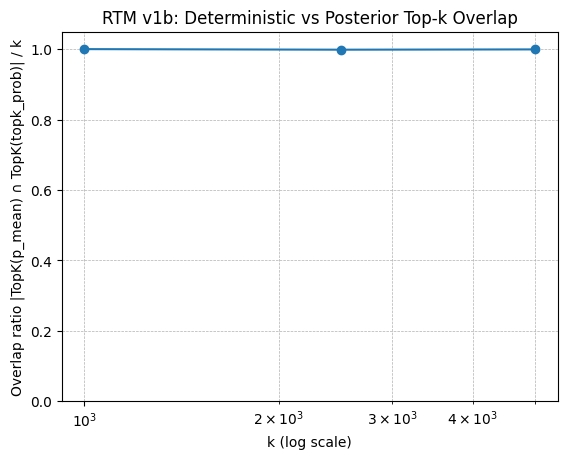

Saved figure: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\decision_stability\v1b\ranking_compare\figures\overlap_ratio_vs_k.png


In [6]:
plt.figure()
plt.plot(summary["k"], summary["overlap_ratio"], marker="o")
plt.xscale("log")
plt.ylim(0, 1.05)
plt.xlabel("k (log scale)")
plt.ylabel("Overlap ratio |TopK(p_mean) ∩ TopK(topk_prob)| / k")
plt.title("RTM v1b: Deterministic vs Posterior Top-k Overlap")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
fig_path = FIG_DIR / "overlap_ratio_vs_k.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved figure:", fig_path)

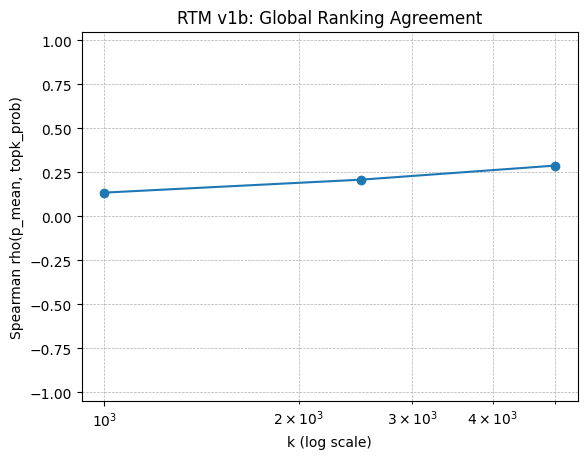

Saved figure: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\decision_stability\v1b\ranking_compare\figures\spearman_rho_vs_k.png


In [7]:
plt.figure()
plt.plot(summary["k"], summary["spearman_rho"], marker="o")
plt.xscale("log")
plt.ylim(-1.05, 1.05)
plt.xlabel("k (log scale)")
plt.ylabel("Spearman rho(p_mean, topk_prob)")
plt.title("RTM v1b: Global Ranking Agreement")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
fig_path = FIG_DIR / "spearman_rho_vs_k.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved figure:", fig_path)

In [8]:
k_inspect = int(summary["k"].iloc[min(3, len(summary)-1)])  # e.g. ~1000 if available
path = DECISION_DIR / f"rtm_decision_stability_v1b_top{k_inspect}.parquet"
df_k = pd.read_parquet(path)

det_rank = df_k["p_mean"].rank(ascending=False, method="average")
post_rank = df_k["topk_prob"].rank(ascending=False, method="average")

df_k2 = df_k.copy()
df_k2["rank_p_mean"] = det_rank
df_k2["rank_topk_prob"] = post_rank
df_k2["rank_diff"] = df_k2["rank_p_mean"] - df_k2["rank_topk_prob"]

# Biggest absolute disagreements
df_k2.reindex(df_k2["rank_diff"].abs().sort_values(ascending=False).head(25).index)[
    ["bldg_id", "p_mean", "topk_prob", "rank_p_mean", "rank_topk_prob", "rank_diff"]
]

,bldg_id,p_mean,topk_prob,rank_p_mean,rank_topk_prob,rank_diff
100158,87563,0.318478,0.0,5135.0,113822.5,-108687.5
100193,93526,0.316027,0.0,5207.0,113822.5,-108615.5
97277,15773,0.315142,0.0,5241.0,113822.5,-108581.5
97244,100858,0.313905,0.0,5274.0,113822.5,-108548.5
126030,1268498,0.311670,0.0,5345.0,113822.5,-108477.5
100184,83408,0.311206,0.0,5356.0,113822.5,-108466.5
125881,1276950,0.310618,0.0,5368.0,113822.5,-108454.5
126025,1268025,0.310410,0.0,5374.0,113822.5,-108448.5
125807,1267719,0.310191,0.0,5382.0,113822.5,-108440.5
126281,1279147,0.310101,0.0,5389.0,113822.5,-108433.5


In [9]:
out_path = OUT_DIR / f"rtm_ranking_disagreements_top{k_inspect}.parquet"
df_k2.to_parquet(out_path, index=False)
print("Saved:", out_path)

Saved: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\decision_stability\v1b\ranking_compare\rtm_ranking_disagreements_top5000.parquet
